# NB02a: SCENE DISCOVERY AND PLAN

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.

1. SLC scene discovery (footprint-verified via slc_scene_discovery.py)  
2. MS scene discovery (coverage-verified via ms_scene_discovery.py, MIN_COVERAGE=90%)  
3. DEM + Orbit downloads  
4. Scene loading + selection + DL-SYNC disk diff  
5. Unified plan builder (scene_plan.build_from_verified)  

# NB02a — Scene Discovery and Unified Plan

<!--
SPDX-License-Identifier: MIT
Text and figures: CC BY 4.0 (https://creativecommons.org/licenses/by/4.0/)
Code: MIT License (https://opensource.org/licenses/MIT)
Published: https://github.com/marcoheinzen/bda
Author: Marco Heinzen
-->

| Field | Value |
|-------|-------|
| **Notebook** | `nb02a_scene_discovery_v6.ipynb` |
| **Version** | v6 |
| **Pipeline position** | Acquisition planning. After NB01b (AOI), before NB02b/c/d (downloads). |
| **License** | Code: MIT / Text and figures: CC BY 4.0 |
| **Repository** | [github.com/marcoheinzen/bda](https://github.com/marcoheinzen/bda) |
| **Last validated** | 2026-04-XX |

## Narrative

This notebook discovers all available Sentinel-1 SLC, Sentinel-1 CARD-BS, and
Sentinel-2 multispectral scenes for all 50 BDA cities, then builds a single
unified plan (`nb02a_scene_plan.json`) that is the **single source of truth**
for the entire downstream pipeline.

The workflow is: (1) discover SLC scenes via Copernicus API with footprint
verification, (2) discover MS scenes with minimum 90% coverage filter,
(3) download DEM and orbit files, (4) load + filter scenes by tier,
(5) reconcile planned orbits against on-disk reality, (6) compute download
sync (what's needed vs what's already on disk), (7) build the unified plan.

**NB02a runs all 50 cities** with no tier filter at discovery time. Tier
filtering only applies in NB02b/c/d when downloading. This ensures the plan
is complete regardless of which tiers are processed.

The plan drives everything: NB02b reads MS scenes from it, NB02c reads CARD
scenes, NB02d reads SLC scenes. NB03a/b/c/d read scene lists and status
from it. All downstream notebooks write `status` fields back into the plan.

## Research Questions Addressed
- **RQ-data:** Which SAR orbits provide consistent coverage per city?
- **RQ-data:** What is the temporal density of Sentinel-1/2 acquisitions over Ukrainian conflict zones?
- **RQ-data:** How many scenes are available per period (pre-battle, battle, post-battle)?

## Scientific Rationale
Sentinel-1 SLC is required for InSAR coherence computation (biweekly repeat pass).
Sentinel-1 CARD-BS provides radiometrically terrain-corrected backscatter without
needing SNAP processing. Sentinel-2 L2A provides multispectral surface reflectance.
The plan ensures temporal coverage across three periods: 12-month pre-war baseline
(Dietrich 2025 protocol), battle period, and post-battle assessment.

Orbit consistency is critical: SLC coherence requires same-orbit pairs, but CARD
products may come from different orbits. The plan tracks `orbit` (SLC/COH) and
`orbit_card` (CARD) as independent fields throughout.

## Inputs

| Data | Source | Format |
|------|--------|--------|
| `AOI.geojson` per city | NB01b Cell 19 | GeoJSON (aoi_bbox for footprint check) |
| `cities_config.json` | Manual | JSON (battle dates, tiers) |
| Copernicus Data Space API | Online | STAC catalog |
| ASF API | Online | Scene metadata |
| OpenTopography API | Online | DEM tiles |
| ESA GNSS orbit files | Online | EOF files |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| `nb02a_scene_plan.json` | `OUTPUTS_DIR/` | **ALL downstream** (NB02b/c/d, NB03a/b/c/d, NB05) |
| SAR metadata JSONs | `SAR_METADATA_DIR/{city}/` | NB02a scene loader |
| MS metadata JSONs | `MS_METADATA_DIR/{city}/` | NB02a scene loader, NB02b |
| DEM tiles | `DEM_DIR/` | NB03a (SNAP GPT coherence) |
| Orbit files (EOF) | `ORBIT_DIR/` | NB03a (SNAP GPT coherence) |
| `bda.sqlite` (scenes table) | `CATALOG_DB` | NB05, NB09 |

## Prerequisites
- NB01b Cell 19 must have run (AOI.geojson per city)
- Copernicus Data Space credentials in `global_setup`
- ASF Earthdata credentials in `global_setup`
- OpenTopography API key in `global_setup`
- Internet access

## Key Methodological Choices

| Choice | Justification | Reference |
|--------|---------------|-----------|
| Footprint verification for SLC | Reject scenes that don't fully cover city bbox | Prevents partial coverage |
| 90% min coverage for MS | Allow slight cloud edge overlap | Balance completeness vs quality |
| All 50 cities at discovery | Plan is complete regardless of tier filter | Enables tier expansion without re-discovery |
| orbit vs orbit_card independent | CARD and SLC orbits may differ for same city | Contamination fix from prior session |
| DEM_BUFFER=0.15 degrees | Ensures DEM covers full SNAP processing extent | SNAP GPT requirement |
| MIN_SLC_SIZE=3GB | Reject truncated/corrupt downloads | Empirical threshold |
| SHORT_CONFLICT_THRESHOLD=30 days | Cities with <30 day battles get special temporal handling | Pipeline robustness |

## Known Limitations
- Copernicus API occasionally returns stale metadata (scenes not yet available)
- ASF API timeout for large date ranges — split into annual queries
- CARD scenes not yet tracked with `orbit_card` in plan (NB02a cells not yet producing it)
- No pre-battle SLC pairs for cities with ongoing conflicts (BUG, fix in Phase 2)
- MS gap-fill (Cell MS-GAPS) may add scenes from adjacent tiles

## Python Modules (loaded by cells)

| Module | Cell | What |
|--------|------|------|
| `slc_scene_discovery.py` | Cell 14A1 | SLC footprint-verified discovery |
| `ms_scene_discovery.py` | Cell 14A1-MS | MS coverage-verified discovery |
| `ms_shopping_list.py` | Cell MS-GAPS | Audit + fill missing MS windows |
| `orbit_downloader.py` | Cell 14A2 | ESA orbit file download |
| `dem_downloader.py` | Cell 14A2-DEM | OpenTopography DEM download |
| `scene_loader.py` | Cell 14A3 | Load metadata into DataFrame |
| `scene_selection.py` | Cell 14B1 | Scene selection logic |
| `tier_filter.py` | Cell 14A-FILTER | Tier-based city filtering |
| `orbit_reconcile.py` | Cell ORBIT-RECONCILE | Override plan orbits from disk |
| `scene_download.py` | Cell 14B2 | Download function init |
| `dl_sync.py` | Cell DL-SYNC | Disk diff: needed vs on-disk |
| `scene_plan.py` | Cell PLAN | Build unified plan JSON |

## Cell Structure

| Cell | ID | What | Status |
|------|----|------|--------|
| 0 | — | Documentation (this cell) | — |
| 1 | Cell 3 | Config (PRODUCT_TYPES, BASELINE_DATES, thresholds) | Config |
| 2 | Cell 4 | Load global_setup | Config |
| 3 | — | Section: Scene Discovery (MD) | — |
| 4 | Cell 14A1 | SLC scene discovery (Copernicus API) | **Core** |
| 5 | Cell 14A1-MS | Multispectral scene discovery | **Core** |
| 6 | Cell MS-GAPS | Audit + fill missing MS windows | **Core** |
| 7 | — | Section: DEM + Orbit Downloads (MD) | — |
| 8 | Cell 14A2 | Download orbit files (ESA) | **Core** |
| 9 | Cell 14A2-DEM | Download global DEM (OpenTopography) | **Core** |
| 10 | — | Section: Scene Loading + Selection (MD) | — |
| 11 | Cell 14A3 | Load scene metadata into DataFrame | **Core** |
| 12 | Cell 14B1 | Scene selection functions | **Core** |
| 13 | Cell 14A-FILTER | Tier selection filter | **Core** |
| 14 | Cell ORBIT-RECONCILE | Override plan orbits from disk truth | **Core** |
| 15 | Cell 14B2 | Scene download function init | **Core** |
| 16 | Cell DL-SYNC | Pre-download sync (disk diff) | **Core** |
| 17 | — | Section: Unified Plan (MD) | — |
| 18 | Cell PLAN | Build unified plan from verified data | **Core** |
| 19 | Cell REUSE | Data reuse report | Diagnostic |
| 20 | Cell SUMMARY | NB02a completion summary | QA |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.2 Data Sources — Sentinel-1 | 14A1 | SLC acquisition strategy, orbit selection |
| 3.2 Data Sources — Sentinel-2 | 14A1-MS, MS-GAPS | MS acquisition, coverage threshold |
| 3.2 Data Sources — Ancillary | 14A2, 14A2-DEM | DEM and orbit files |
| 3.3 Preprocessing — Scene Selection | 14A3, 14B1, 14A-FILTER | Temporal windows, tier strategy |
| 3.3 Preprocessing — Plan Architecture | PLAN | nb02a_scene_plan.json as single source of truth |

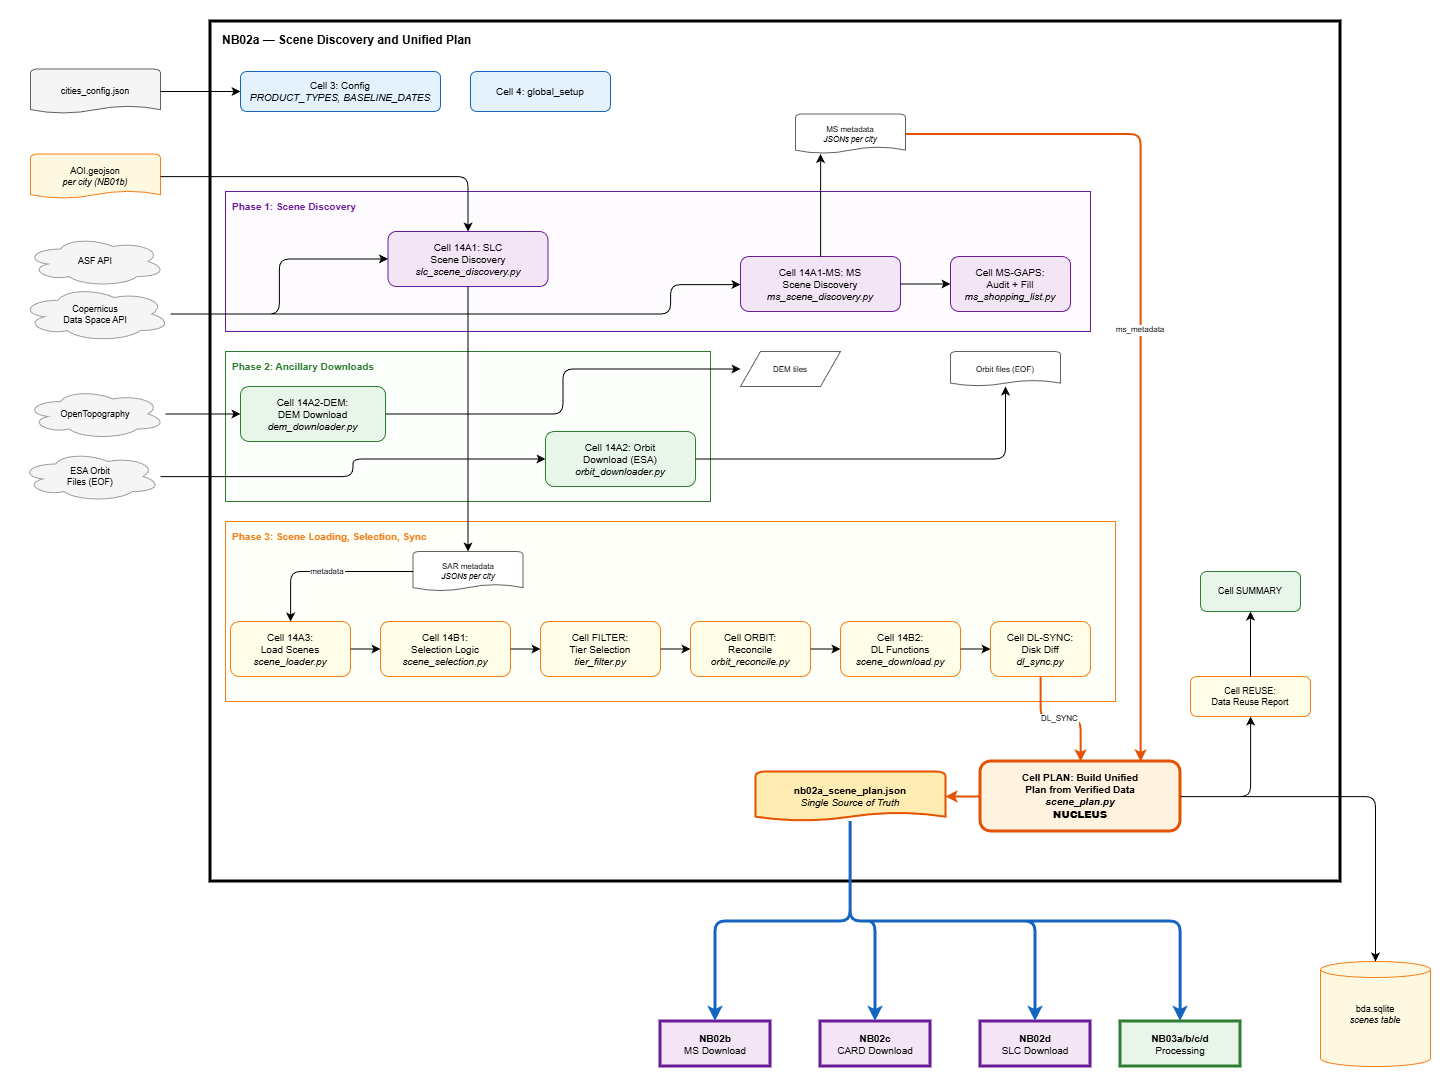

In [1]:
# @title CELL 3: NB02a CONFIG
CITY_SELECTION = None           # or ["Mariupol"]
PRODUCT_TYPES = ["SLC"]
BASELINE_DATES = {
    'pre_2022': {'start': '2021-09-01', 'end': '2022-02-22', 'ideal_start': '2022-01-01', 'ideal_end': '2022-02-22'},
    'post_2025': {'start': '2025-01-01', 'end': '2025-12-31', 'ideal_start': '2025-09-01', 'ideal_end': '2025-12-31'}
}
DEM_BUFFER = 0.15
MIN_SLC_SIZE = 3e9
MIN_CARD_SIZE = 1e9
REQUIRE_SAR_ALIGNED = True
SHORT_CONFLICT_THRESHOLD_DAYS = 30
MS_SAR_WINDOW_DAYS = 30
MS_CLOUD_STRICT = 1
MS_CLOUD_RELAXED = 5
MS_CLOUD_MAX = 10
MS_MIN_COVERAGE_PCT = 90
MS_SCENES_PER_PERIOD = 2
MS_WINTER_MONTHS = [10, 11, 12, 1, 2]
MS_BASELINE_N_SCENES = 5
MS_BASELINE_MAX_CLOUD = 15

In [2]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())

BDA GLOBAL SETUP
Started: 2026-04-08 01:48:07
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:501: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     911.1/7452.0 GB (6540.9 GB free)
  GDrive (F:)     537.2/3726.0 GB (3188.8 GB free)
  Local data      10666.6/14901.9 GB (4235.2 GB free)
  Data stack      537.2/3726.0 GB (3188.8 GB free)
  WSL ext4        103.9/1006.9 GB (851.8 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_b

# SCENE DISCOVERY

In [3]:
# @title CELL 14A1: SCENE DISCOVERY
FORCE_RERUN = True
PRODUCT_TYPES = ["SLC"]

import sys
from pathlib import Path
_nb_dir = Path.cwd().parent  # notebooks/
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from slc_scene_discovery import run as run_scene_discovery
run_scene_discovery(
    cities_dir=CITIES_DIR,
    logs_dir=LOGS_DIR,
    output_dir=SAR_METADATA_DIR,
    progress_file=SLC_PROGRESS_FILE,
    product_types=PRODUCT_TYPES,
    force_rerun=FORCE_RERUN,
)


CELL 14A1: SCENE DISCOVERY AND TEMPORAL WINDOWS - MULTI-ORBIT
Start time: 2026-04-08T01:48:58.368820
Product types: ['SLC']
Storage location: /content/drive_f/masterthesis/data/satellite/SAR_METADATA
Pre-months: 14
Proximity days: 14

  FORCE_RERUN = True - Clearing progress...

  Found 50 cities

################################################################################
# CITY 1/50: Avdiivka
################################################################################

CITY: Avdiivka

  City bounds: [37.690, 48.107, 37.808, 48.177]
  City center: (48.141, 37.754)
  Bbox size: 8.7 x 7.8 km

  Tier: 2
  Battle dates:
    Start: 2022-02-24
    End: 2024-02-17

  Search windows (proximity: 14 days, pre: 14 months):
    Pre-battle:  2020-12-24 to 2022-02-10
    Post-battle: 2024-03-02 to 2025-04-17
    Battle duration: 723 days

  Searching pre-battle SLC scenes...

  Searching all sources: 2020-12-24 to 2022-02-10
    Querying Copernicus (asc)...
    Copernicus (asc): 1 pages fe

In [4]:
# @title CELL 14A1-MS: MULTISPECTRAL SCENE DISCOVERY
FORCE_RERUN = True

import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import ms_scene_discovery
importlib.reload(ms_scene_discovery)
from ms_scene_discovery import run as run_ms_discovery
run_ms_discovery(
    cities_dir=CITIES_DIR,
    logs_dir=LOGS_DIR,
    sar_metadata_dir=SAR_METADATA_DIR,
    ms_metadata_dir=MS_METADATA_DIR,
    ms_progress_file=MS_PROGRESS_FILE,
    outputs_dir=OUTPUTS_DIR,
    force_rerun=FORCE_RERUN,
    city_selection=CITY_SELECTION,
    sar_date_window_days=MS_SAR_WINDOW_DAYS,
    cloud_cover_strict=MS_CLOUD_STRICT,
    cloud_cover_relaxed=MS_CLOUD_RELAXED,
    cloud_cover_max=MS_CLOUD_MAX,
    min_coverage_pct=MS_MIN_COVERAGE_PCT,
    scenes_per_period=MS_SCENES_PER_PERIOD,
    winter_months=MS_WINTER_MONTHS,
    baseline_n_scenes=MS_BASELINE_N_SCENES,
    baseline_max_cloud=MS_BASELINE_MAX_CLOUD,
)


CELL 14A1-MS: MULTISPECTRAL SCENE DISCOVERY (SAR-ALIGNED + FALLBACK)
Start time: 2026-04-08T03:02:25.954606
SAR date window: +-30 days
Scenes per period: 2
Cloud thresholds: 3.0% / 5.0% / 15.0%
Min coverage: 95.0%
SAR metadata: /content/drive_f/masterthesis/data/satellite/SAR_METADATA
MS metadata:  /content/drive_f/masterthesis/data/satellite/MS/metadata

Fallback logic:
  If <2 scenes around SAR dates:
    Pre-battle:  search backwards from battle_start (60d/90d/120d)
    Post-battle: search forwards from battle_end (60d/90d/120d)

  FORCE_RERUN = True - Clearing progress...

  Found 50 cities
  SAR metadata available: 50/50 cities

################################################################################
# CITY 1/50: Avdiivka
################################################################################

CITY: Avdiivka

  Tier: 2
  Battle: 2022-02-24 to 2024-02-17

  SAR alignment mode:
    Pre-battle SAR dates:  ['2021-01-02', '2021-01-08']
    Post-battle SAR dates: ['202

In [5]:
# @title CELL MS-GAPS: AUDIT + FILL MISSING MS SCENE WINDOWS
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
TIER_SELECTION =[0,1,2,3,4,5]
import ms_shopping_list
importlib.reload(ms_shopping_list)
from ms_shopping_list import audit_metadata, fill_gaps

# 1. Audit: see what's missing
audit = audit_metadata(MS_METADATA_DIR, tier_selection=TIER_SELECTION, city_selection=CITY_SELECTION)

# 2. Fill gaps (set dry_run=True to preview without API calls)
fill_gaps(
    cities_dir=CITIES_DIR,
    ms_metadata_dir=MS_METADATA_DIR,
    sar_metadata_dir=SAR_METADATA_DIR,
    outputs_dir=OUTPUTS_DIR,
    tier_selection=TIER_SELECTION,
    city_selection=CITY_SELECTION,
    baseline_n_scenes=5,
    baseline_max_cloud=15,
    dry_run=False,
)


MS SHOPPING LIST: METADATA AUDIT

  Cities audited: 50
  Total gaps: 167

  City                      Tier   pre post   bl  pbl  bat   bw preb
  ------------------------- ----  ---- ---- ---- ---- ---- ---- ----
  Avdiivka                  T 2    2+   2+   5+   5+  ---  14+   1+
  Bakhmut                   T 3    2+   2+   5+   3+  ---   7+   2+
  Balakliia                 T 3    2+   2+   5+   5+  ---  ---  ---
  Borodyanka                T 1    0!   0!  ---  ---  ---  ---  ---
  Bucha                     T 1    2+   2+   5+   4+  ---  ---  ---
  Chasiv Yar                T 5    2+   1!   5+  skp  ---  ---  ---
  Chernihiv                 T 1    2+   2+   5+   5+  ---  ---  ---
  Chornobaivka              T 2    2+   2+   5+   5+  ---  ---  ---
  Chuhuiv                   T 3    2+   2+   5+   5+  ---  ---  ---
  Dmytrivka                 T 1    2+   2+   5+   2!  ---  ---  ---
  Dnipro                    T 5    2+   2+   5+  skp  ---  ---  ---
  Hirske                    T 4    0!   

{'Avdiivka': {'tier': 2,
  'conflict_ongoing': False,
  'windows': {'pre_window': {'status': 'ok',
    'n_scenes': 2,
    'min_needed': 2,
    'needs_sar': True,
    'description': 'SAR-aligned pre-battle'},
   'post_window': {'status': 'ok',
    'n_scenes': 2,
    'min_needed': 2,
    'needs_sar': True,
    'description': 'SAR-aligned post-battle'},
   'baseline_window': {'status': 'ok',
    'n_scenes': 5,
    'min_needed': 3,
    'needs_sar': False,
    'description': 'pre-battle winter baseline'},
   'post_baseline_window': {'status': 'ok',
    'n_scenes': 5,
    'min_needed': 3,
    'needs_sar': False,
    'description': 'post-battle winter baseline'},
   'battle_window': {'status': 'missing',
    'n_scenes': 0,
    'min_needed': 0,
    'needs_sar': True,
    'description': 'during-battle (T0 only)'},
   'biweekly_window': {'status': 'ok',
    'n_scenes': 14,
    'min_needed': 0,
    'needs_sar': True,
    'description': 'SAR-aligned biweekly'},
   'prebattle_baseline_window': {'st

# DEM + ORBIT DOWNLOADS

In [6]:
# @title CELL 14A2: DOWNLOAD ORBIT FILES
FORCE_RERUN = False

import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import orbit_downloader
importlib.reload(orbit_downloader)
from orbit_downloader import run as run_orbit_download

run_orbit_download(
    orbits_dir=LOCAL_ORBITS_DIR,
    force_rerun=FORCE_RERUN,
)

Orbit files already downloaded
  Last updated: 2026-04-06T02:02:48.901187
  Total files: 2667
  Total size: 2.05 GB

Set FORCE_RERUN=True to re-download
Cell 14A2: Orbit download complete


In [7]:
# @title CELL 14A2-DEM: DOWNLOAD GLOBAL DEM
FORCE_RERUN = False

import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import dem_downloader
importlib.reload(dem_downloader)
from dem_downloader import run as run_dem_download, clip_dem_to_bounds

run_dem_download(
    cities_dir=CITIES_DIR,
    dem_dir=LOCAL_DEM_DIR,
    opentopo_key=OPENTOPO_KEY,
    force_rerun=FORCE_RERUN,
    dem_buffer=DEM_BUFFER,
)


CELL 14A2-DEM: DOWNLOAD GLOBAL DEM (RUN ONCE)

  Step 1: Computing combined bbox from all city boundaries...
    Cities: 50
    Combined bbox: [23.77, 46.19, 38.95, 51.70]
    Approx DEM size: 54662 x 19841 pixels

  Step 2: Downloading SRTM DEM...
    DEM already exists: srtm_all_cities.tif
    Size: 54662 x 19842
    Bounds: [23.77, 46.19, 38.95, 51.70]

  Step 3: clip_dem_to_bounds() available
    Usage: clip_dem_to_bounds((west, south, east, north), output_path)

CELL 14A2-DEM COMPLETE - Global DEM: /content/masterthesis_local/data/dem/srtm_all_cities.tif


# SCENE LOADING + SELECTION + DL-SYNC

In [8]:
# @title CELL 14A3: LOAD SCENES
FORCE_RERUN = True

import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import scene_loader
importlib.reload(scene_loader)
from scene_loader import run as run_scene_loader

cities_df = run_scene_loader(
    cities_dir=CITIES_DIR,
    sar_metadata_dir=SAR_METADATA_DIR,
    cities_pkl_file=CITIES_PKL_FILE,
    force_rerun=FORCE_RERUN,
)

CELL 14A3: LOAD SCENES FROM GOOGLE DRIVE

  FORCE_RERUN = True
  Rebuilding cities dataframe from source JSON files...
Building cities dataframe from JSON metadata files...
  Built dataframe with 50 cities

  Saving cities dataframe to pickle...
  Saved to: /content/drive_f/masterthesis/data/satellite/SAR_METADATA/cities_dataframe.pkl

CITIES DATAFRAME LOADED
Source: /content/drive_f/masterthesis/data/satellite/SAR_METADATA
Cache: /content/drive_f/masterthesis/data/satellite/SAR_METADATA/cities_dataframe.pkl

Cities summary:
   1. [T0] Lysychansk          : 57 pre, 33 post, 1 battle, Battle: 2022-06-25 - 2022-07-03 | Orbit: 94
   2. [T0] Mariupol            : 63 pre, 35 post, 7 battle, Battle: 2022-02-24 - 2022-05-20 | Orbit: 43
   3. [T0] Rubizhne            : 63 pre, 36 post, 6 battle, Battle: 2022-03-04 - 2022-05-12 | Orbit: 145
   4. [T0] Sievierodonetsk     : 59 pre, 35 post, 5 battle, Battle: 2022-05-05 - 2022-06-25 | Orbit: 145
   5. [T1] Borodyanka          : 64 pre, 32 post, 3

In [9]:
# @title CELL 14B1: SCENE SELECTION FUNCTIONS
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import scene_selection
importlib.reload(scene_selection)
from scene_selection import init as init_scene_selection

init_scene_selection(
    cities_dir=CITIES_DIR,
    sar_metadata_dir=SAR_METADATA_DIR,
    data_root=DATA_ROOT,
    min_temporal_baseline=MIN_TEMPORAL_BASELINE,
    max_temporal_baseline=MAX_TEMPORAL_BASELINE,
    prebattle_tolerance_days=PREBATTLE_TOLERANCE_DAYS,
)

# functions now available:
from scene_selection import (
    select_scene_pair, select_biweekly_chain, select_prebattle_baseline,
    get_city_info, get_available_orbits_for_city, load_discovered_scenes,
    query_scenes_for_city, check_orbit_available, deduplicate_scenes_by_date,
)


CELL 14B1: SCENE SELECTION FUNCTIONS
  asf_search: AVAILABLE

  Functions defined:
    get_city_info(city_name)
    load_discovered_scenes(city_name)
    search_copernicus_scenes(start_date, end_date, bounds, ...)
    filter_scenes_by_footprint(scenes_list, city_geometry, verbose)
    query_asf_scenes_for_city(city_info, start_date, end_date, orbit)
    query_scenes_for_city(city_info, start_date, end_date, orbit)
    deduplicate_scenes_by_date(scenes)
    select_scene_for_city(city_name, period, scene_index, orbit, orbit_direction, exclude_scenes)
    select_pair_scene(city_name, period, anchor_scene, orbit, orbit_direction, exclude_scenes)
    select_scene_pair(city_name, period, orbit, orbit_direction, exclude_scenes)
    get_available_orbits_for_city(city_name)
    select_biweekly_chain(city_name, orbit, orbit_direction, start_date, end_date)
    select_prebattle_baseline(city_name, n_scenes, orbit, orbit_direction)

CELL 14B1 COMPLETE


In [10]:
# @title CELL 14A-FILTER: TIER SELECTION FILTER
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
TIER_SELECTION = [0,1,2,3,4,5]
import tier_filter
importlib.reload(tier_filter)
from tier_filter import run as run_tier_filter

cities_df_filtered, ms_cities_df_filtered, SAR_CITIES_TO_PROCESS, MS_CITIES_TO_PROCESS, CITIES_TO_PROCESS = run_tier_filter(
    cities_df=cities_df,
    tier_selection=TIER_SELECTION,
    city_selection=CITY_SELECTION,
    min_pre_scenes=MIN_PRE_SCENES,
    min_post_scenes=MIN_POST_SCENES,
    require_sar_aligned=REQUIRE_SAR_ALIGNED,
)

CELL 14A-FILTER: TIER SELECTION FILTER
Timestamp: 2026-04-08T05:05:54.150223

Source dataframes:
  cities_df (SAR):    50 cities
  ms_cities_df (MS):  not provided (SAR-only mode)

FILTER CONFIGURATION:
  TIER_SELECTION:     [0, 1, 2, 3, 4, 5]
  CITY_SELECTION:     None
  MIN_PRE_SCENES:     3
  MIN_POST_SCENES:    3
  REQUIRE_SAR_ALIGNED: True

FILTERING SAR DATAFRAME (cities_df)
  Starting with 50 cities
  After tier filter: 50 cities
  After min pre-scenes filter: 50 cities
  After min post-scenes filter: 50 cities

FILTER RESULTS

SAR cities to process: 50
MS cities to process:  0
Cities in BOTH:        0

Tier breakdown (filtered):
  Tier 0: 4 SAR, 0 MS
  Tier 1: 11 SAR, 0 MS
  Tier 2: 6 SAR, 0 MS
  Tier 3: 10 SAR, 0 MS
  Tier 4: 8 SAR, 0 MS
  Tier 5: 11 SAR, 0 MS

Cities in SAR but not MS (50):
    - Avdiivka
    - Bakhmut
    - Balakliia
    - Borodyanka
    - Bucha
    - Chasiv Yar
    - Chernihiv
    - Chornobaivka
    - Chuhuiv
    - Dmytrivka
    - Dnipro
    - Hirske
    - 

In [11]:
# @title CELL ORBIT-RECONCILE: OVERRIDE PLAN ORBIT FROM DISK TRUTH
DRY_RUN_ORBIT = False

import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import orbit_reconcile
importlib.reload(orbit_reconcile)
from orbit_reconcile import run as run_orbit_reconcile

cities_df = run_orbit_reconcile(
    cities_df=cities_df,
    sar_card_dir=SAR_CARD_DIR,
    sar_coh_dir=SAR_COH_DIR,
    dry_run=DRY_RUN_ORBIT,
    sar_filtered=cities_df_filtered,
)


ORBIT RECONCILE: DISK TRUTH vs PLAN (per-modality)
  Timestamp: 2026-04-08T05:05:54.224531
  DRY_RUN: False

  Scanning CARD TIFs in /content/drive_f/masterthesis/data/satellite/SAR_CARD ...
    26 cities with CARD TIFs
  Scanning COH TIFs in /content/drive_f/masterthesis/data/satellite/SAR_COH ...
    11 cities with COH TIFs

  tier city                    plan CARD_o    n  pre  pst  COH_o    n  pre  pst  action
  ---- ---------------------- ----- ------ ---- ---- ---- ------ ---- ---- ----  -------------------------
    T0 Lysychansk              o094   o094    7    4    2   o094    5    3    1  OK
    T0 Mariupol                o043   o043   14    5    2   o043    5    4    1  OK
    T0 Rubizhne                o145   o145   13    5    2   o145    5    0    1  OK COH:NO_PRE!
    T0 Sievierodonetsk         o145   o145    8    5    0   o145    6    5    0  OK CARD:NO_POST! COH:NO_POST!

    T1 Borodyanka              o160   o087   10    5    2      -    0    0    0  *** CARD->o087
    

In [12]:
# @title CELL 14B2: SCENE DOWNLOAD FUNCTIONS
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import scene_download
importlib.reload(scene_download)
from scene_download import init as init_scene_download

init_scene_download(
    temp_download_dir=TEMP_DOWNLOAD_DIR,
    raw_slc_zip=RAW_SLC_ZIP,
    data_root=DATA_ROOT,
    copernicus_username=COPERNICUS_USERNAME,
    copernicus_password=COPERNICUS_PASSWORD,
)

from scene_download import (
    download_scene, download_scene_pair, download_scene_chain,
    download_orbit_files, cleanup_temp_scenes,
    download_scene_copernicus, download_scene_asf,
    get_copernicus_token, lookup_copernicus_id,
)


CELL 14B2: SCENE DOWNLOAD FUNCTIONS

  Functions defined:
    get_copernicus_token()
    lookup_copernicus_id(scene_name)
    download_scene_copernicus(scene_id, scene_name, output_dir)
    download_scene_asf(scene_name, output_dir, earthdata_user, earthdata_pass)
    download_scene(scene_metadata, output_dir, prefer_copernicus)
    download_scene_pair(scene1, scene2, output_dir, prefer_copernicus)
    download_orbit_files(scene_paths, orbit_source_dir, orbit_dest_dir)
    cleanup_temp_scenes(scene_names, keep_safe)
    download_scene_chain(chain, output_dir, prefer_copernicus)

  Config:
    TEMP_DOWNLOAD_DIR = /content/snap_work/temp
    RAW_SLC_ZIP = /content/masterthesis_local/data/raw_slc_zip
    Download preference: Copernicus FIRST, ASF fallback

CELL 14B2 COMPLETE


In [13]:
# @title CELL DL-SYNC: PRE-DOWNLOAD SYNC
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import dl_sync
importlib.reload(dl_sync)
from dl_sync import run as run_dl_sync

DL_SYNC = run_dl_sync(
    cities_df=cities_df,
    sar_filtered=cities_df_filtered,
    raw_slc_zip=RAW_SLC_ZIP,
    card_zip_dir=CARD_ZIP_DIR,
    ms_zip_dir=MS_ZIP_DIR,
    sar_card_dir=SAR_CARD_DIR,
    outputs_dir=OUTPUTS_DIR,
    card_tracker_file=CARD_TRACKER_FILE,
    slc_plan_file=SLC_PLAN_FILE,
    card_plan_file=CARD_PLAN_FILE,
    n_prebattle_baseline=N_PREBATTLE_BASELINE,
    short_conflict_threshold_days=SHORT_CONFLICT_THRESHOLD_DAYS,
    min_slc_size=MIN_SLC_SIZE,
    min_card_size=MIN_CARD_SIZE,
)

CELL DL-SYNC: PRE-DOWNLOAD SYNC
  Timestamp: 2026-04-08T05:05:54.506141
  N_PREBATTLE_BASELINE: 5
  SHORT_CONFLICT_THRESHOLD: 30d
  cities_df:          50 cities (ALL tiers)
  sar_filtered:       50 cities (filtered tiers)

STEP 1A: SCANNING SLC ZIPS ON DISK
  RAW_SLC_ZIP: /content/masterthesis_local/data/raw_slc_zip
  Found 806 valid SLC zips (6425 GB)
  Unique dates: 745

STEP 1B: SCANNING CARD ZIPS ON DISK
  CARD_ZIP_DIR: /content/masterthesis_local/data/card_zip
  Found 1200 valid CARD zips

STEP 1C: SCANNING CARD TIFS ON DISK
  SAR_CARD_DIR: /content/drive_f/masterthesis/data/satellite/SAR_CARD
  Found CARD TIFs for 26 cities, 565 city-dates

STEP 1D: SCANNING MS ZIPS ON DISK
  MS_ZIP_DIR: /content/masterthesis_local/data/ms_zip
  Found 1195 MS zips

STEP 2: LOADING EXISTING TRACKERS
  SLC tracker: 845 entries
  CARD tracker: 2868 entries
  MS tracker: 2 entries

STEP 3: SCENE SELECTION - ALL TIERS (PROTECTION SET)
  Processing 50 cities for protection set...
    Lysychansk: SHORT

# UNIFIED PLAN

In [14]:
# @title CELL PLAN: BUILD UNIFIED PLAN FROM VERIFIED DATA
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import scene_plan
importlib.reload(scene_plan)
from scene_plan import build_from_verified, compute_reuse_report

PLAN = build_from_verified(
    dl_sync=DL_SYNC,
    ms_metadata_dir=MS_METADATA_DIR,
    cities_dir=CITIES_DIR,
    outputs_dir=OUTPUTS_DIR,
    catalog_db=CATALOG_DB,
    sar_card_dir=SAR_CARD_DIR,
    cities_df=cities_df,
)

BUILDING UNIFIED PLAN FROM VERIFIED DATA
  CARD TIFs on disk: 565 dates across 27 cities
  DEBUG Avdiivka: cities_df cols=['city', 'tier', 'product_types', 'battle_start', 'battle_end'], recommended_orbit_card=True, oc=94, orbit_card=94
  Avdiivka               T2 orbit=94  SLC=66/66  CARD=65/66  MS=24/24
  Bakhmut                T3 orbit=43  SLC=38/38  CARD=36/38  MS=18/18
  Balakliia              T3 orbit=116  SLC=23/23  CARD=23/23  MS=14/14
  Borodyanka             T1 orbit=160  SLC=9/10  CARD=0/10  (disk:10)  MS=0/0
  Bucha                  T1 orbit=87  SLC=10/10  CARD=0/10  (disk:9)  MS=13/13
  Chasiv Yar             T5 orbit=145  SLC=91/92  CARD=0/92  (disk:87)  MS=7/7
  Chernihiv              T1 orbit=138  SLC=2/10  CARD=10/10  MS=14/14
  Chornobaivka           T2 orbit=138  SLC=17/28  CARD=27/28  MS=12/12
  Chuhuiv                T3 orbit=116  SLC=13/13  CARD=0/13  (disk:13)  MS=14/14
  Dmytrivka              T1 orbit=87  SLC=10/10  CARD=0/10  (disk:9)  MS=11/11
  Dnipro       

In [15]:
# @title CELL REUSE: DATA REUSE REPORT
from scene_plan import compute_reuse_report
if 'PLAN' in dir() and PLAN:
    _ = compute_reuse_report(PLAN)
else:
    print("Run CELL PLAN first")

REUSE REPORT: EXISTING DATA vs DOWNLOAD NEEDED

  SLC  [##################################......]  86.4% reusable
       on_disk=1964  to_download=309  total=2273
       estimated download: ~2472 GB

  CARD [#######.................................]  17.7% reusable
       on_disk=403  to_download=1870  total=2273
       estimated download: ~7480 GB

  MS   [#######################################.]  98.1% reusable
       on_disk=522  to_download=10  total=532
       estimated download: ~10 GB

  Total estimated download: ~9962 GB

  Per-period breakdown:

    SLC:
      biweekly_2022-02-25          4/4    on disk (100.0%)  dl=0
      biweekly_2022-02-26          1/1    on disk (100.0%)  dl=0
      biweekly_2022-02-28          4/4    on disk (100.0%)  dl=0
      biweekly_2022-03-03          5/6    on disk ( 83.3%)  dl=1
      biweekly_2022-03-04          4/4    on disk (100.0%)  dl=0
      biweekly_2022-03-05          5/6    on disk ( 83.3%)  dl=1
      biweekly_2022-03-07          2/6 

In [16]:
# @title CELL SUMMARY: NB02a COMPLETE
print("=" * 80)
print("NB02a SCENE DISCOVERY + PLAN - COMPLETE")
print("=" * 80)
plan_file = OUTPUTS_DIR / 'nb02a_scene_plan.json'
print(f"  Plan: {plan_file} ({'EXISTS' if plan_file.exists() else 'MISSING'})")
print(f"  DB:   {CATALOG_DB}")
print(f"\nNext: NB02b (MS) -> NB02c (CARD) -> NB02d (SLC)")
print("=" * 80)

NB02a SCENE DISCOVERY + PLAN - COMPLETE
  Plan: /content/drive_f/masterthesis/data/outputs/nb02a_scene_plan.json (EXISTS)
  DB:   /mnt/f/PROJECTS/masterthesis/data_stack/bda.sqlite

Next: NB02b (MS) -> NB02c (CARD) -> NB02d (SLC)
